# EDA: Whole Dataset (50k sample)

This notebook contains exploratory data analysis for the large portion (50k) of the chest X-ray metadata.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

### Loading Data

In [2]:
file_path = '../data/metadata_filtered.csv'
df = pd.read_csv(file_path)

print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (54999, 2)


,Image Index,Finding Labels
0,00000001_000.png,Cardiomegaly
1,00000001_001.png,Cardiomegaly|Emphysema
2,00000001_002.png,Cardiomegaly|Effusion
3,00000002_000.png,No Finding
4,00000003_001.png,Hernia


### Statistical Overview

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54999 entries, 0 to 54998
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Image Index     54999 non-null  object
 1   Finding Labels  54999 non-null  object
dtypes: object(2)
memory usage: 859.5+ KB


,Image Index,Finding Labels
count,54999,54999
unique,54999,567
top,00000001_000.png,No Finding
freq,1,31161


### Pathology Finding Distribution
We extract the findings and plot their prevalence.

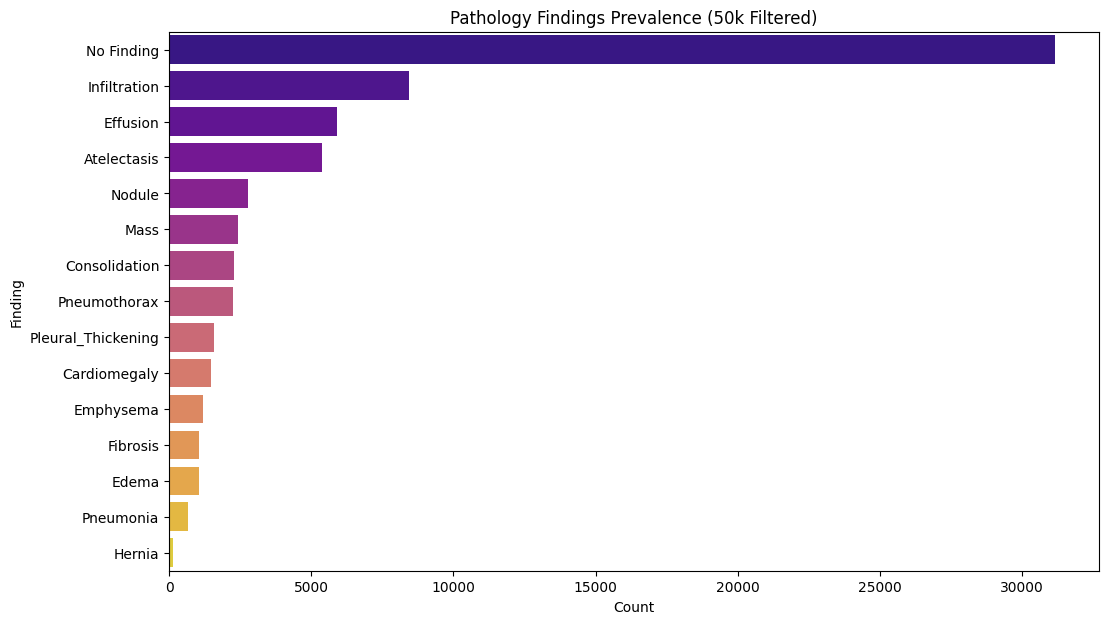

In [4]:
all_labels = df['Finding Labels'].str.split('|').explode().value_counts()
plt.figure(figsize=(12, 7))
sns.barplot(x=all_labels.values, y=all_labels.index, hue=all_labels.index, palette='plasma', legend=False)
plt.title('Pathology Findings Prevalence (50k Filtered)')
plt.xlabel('Count')
plt.ylabel('Finding')
plt.show()

### Top finding Combinations

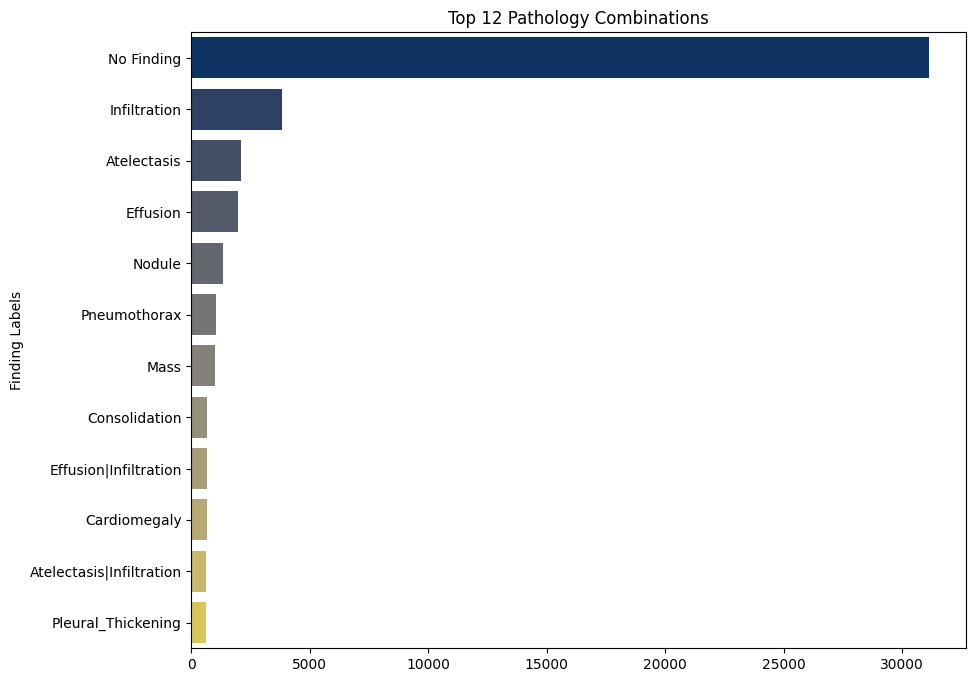

In [5]:
combos = df['Finding Labels'].value_counts().head(12)
plt.figure(figsize=(10, 8))
sns.barplot(x=combos.values, y=combos.index, hue=combos.index, palette='cividis', legend=False)
plt.title('Top 12 Pathology Combinations')
plt.show()

### Label Correlation Matrix

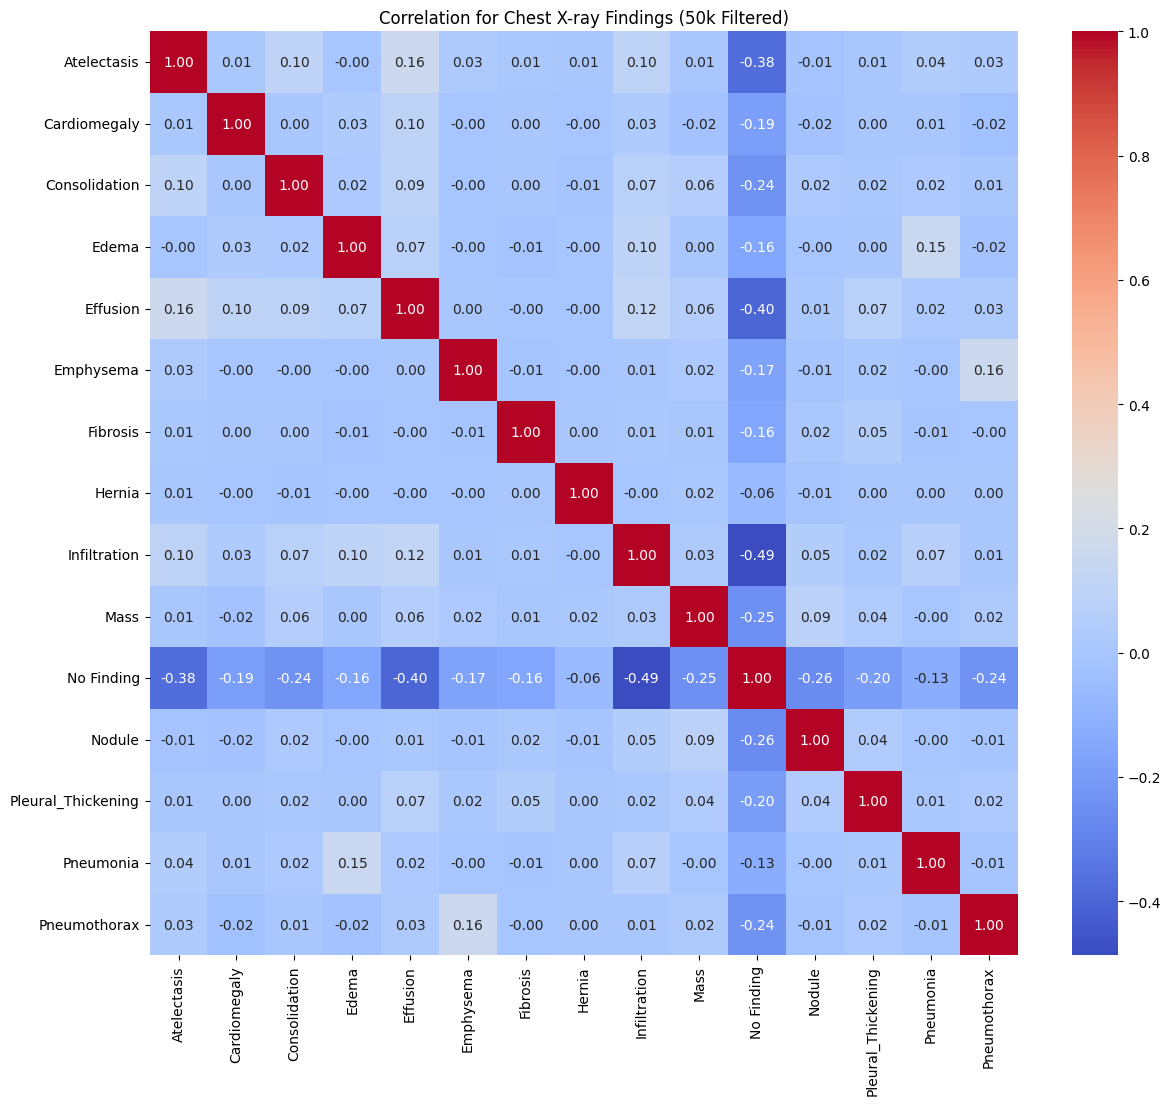

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df['Finding Labels'].str.split('|'))
rdf = pd.DataFrame(encoded, columns=mlb.classes_)

plt.figure(figsize=(14, 12))
sns.heatmap(rdf.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation for Chest X-ray Findings (50k Filtered)')
plt.show()